In [4]:
import pandas as pd
data = {
    "day": list(range(1, 16)),
    "sales": [120,135,128,150,160,155,170,180,175,190,200,210,195,205,215],
    "city": ["Almaty","Astana","Almaty","Shymkent","Almaty",
             "Astana","Almaty","Shymkent","Astana","Almaty",
             "Shymkent","Astana","Almaty","Shymkent","Astana"]
}
df = pd.DataFrame(data)
df.to_csv("sales.csv", index=False)
df

,day,sales,city
0,1,120,Almaty
1,2,135,Astana
2,3,128,Almaty
3,4,150,Shymkent
4,5,160,Almaty
5,6,155,Astana
6,7,170,Almaty
7,8,180,Shymkent
8,9,175,Astana
9,10,190,Almaty


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import json

In [7]:
class CSVAnalyzer:
    def __init__(self, file):
        self.df = pd.read_csv(file)
    def rows(self):
        return len(self.df)
    def numeric_cols(self):
        nums = []
        for col in self.df.columns:
            try:
                self.df[col].astype(float)
                nums.append(col)
            except:
                pass
        return nums
    def missing(self):
        return self.df.isna().sum()
    def describe(self):
        return self.df.describe()
    def stats_two_cols(self):
        cols = self.numeric_cols()[:2]
        result = {}
        for c in cols:
            arr = self.df[c].to_numpy()
            result[c] = {
                "min": np.min(arr),
                "max": np.max(arr),
                "mean": np.mean(arr)
            }
        return result
    def lag_and_rolling(self):
        self.df["sales_lag_1"] = self.df["sales"].shift(1)
        self.df["sales_roll_3"] = self.df["sales"].rolling(3).mean()
        self.df.to_csv("sales_with_lag.csv", index=False)
    def top_categories(self):
        return self.df["city"].value_counts().head(5)
    def histogram(self):
        self.df["sales"].hist()
        plt.title("Histogram sales")
        plt.savefig("histogram.png")
        plt.show()
    def bar_chart(self):
        self.top_categories().plot(kind="bar")
        plt.title("Top cities")
        plt.savefig("top_categories.png")
        plt.show()
    def json_export(self):
        data = {
            "n_rows": self.rows(),
            "describe": self.describe().to_dict(),
            "top_categories": self.top_categories().to_dict()
        }
        with open("result.json","w") as f:
            json.dump(data,f,indent=4)

Rows: 15
Numeric columns: ['day', 'sales']
Missing values:
 day      0
sales    0
city     0
dtype: int64
Stats for two numeric columns:
 {'day': {'min': np.int64(1), 'max': np.int64(15), 'mean': np.float64(8.0)}, 'sales': {'min': np.int64(120), 'max': np.int64(215), 'mean': np.float64(172.53333333333333)}}


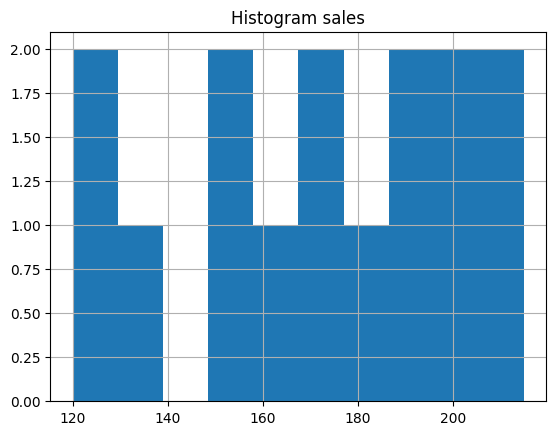

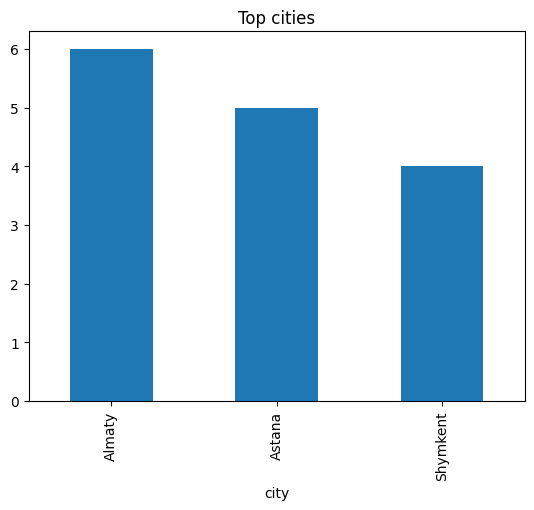

In [8]:
an = CSVAnalyzer("sales.csv")
print("Rows:", an.rows())
print("Numeric columns:", an.numeric_cols())
print("Missing values:\n", an.missing())
print("Stats for two numeric columns:\n", an.stats_two_cols())
an.lag_and_rolling()
an.histogram()
an.bar_chart()
an.json_export()